# Notebook 06 V3 — Optimisation énergétique SWRO — version corrigée

**PFE — Master Science des Données**

### Correction de l'erreur du Notebook 06 V2

Le Notebook 02 n'a pas sauvegardé un objet `scaler.pkl`. Il a sauvegardé les paramètres du `StandardScaler` dans :

`data/preprocessed/scaler_parameters.csv`

Le Notebook 04 utilise directement les fichiers `X_train_scaled.csv`, `X_val_scaled.csv` et `X_test_scaled.csv`.

Cette V3 reconstruit donc **exactement la transformation StandardScaler à partir de `scaler_parameters.csv`**, sans recréer un scaler à partir du test.

Le dataset physique utilisé est celui du projet :

`data/dataset_physical_v3.csv`

Les bornes physiques de départ proviennent du modèle physique SWRO V3 ; elles sont indiquées explicitement dans le notebook et peuvent être remplacées par des limites industrielles réelles.

In [1]:
# 0. Imports et configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from scipy.optimize import differential_evolution, minimize

MODEL_DIR = Path("models")
DATA_DIR = Path("data/preprocessed")
RESULT_DIR = Path("results")
PHYSICAL_DATA_PATH = Path("data/dataset_physical_v3.csv")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model_optimized.pkl"
SCALER_PARAMS_PATH = DATA_DIR / "scaler_parameters.csv"

FEATURES = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

TARGET = "SEC_kWh_m3"

print("Configuration chargée.")

Configuration chargée.


## 1. Vérifier les fichiers du projet

Cette cellule donne une erreur explicite si un fichier réellement nécessaire manque.

In [2]:
required_files = {
    "Modèle MLP": MODEL_PATH,
    "Paramètres du scaler": SCALER_PARAMS_PATH,
    "Dataset physique V3": PHYSICAL_DATA_PATH,
}

for name, file_path in required_files.items():
    print(f"{name}: {file_path} -> {'OK' if file_path.exists() else 'MANQUANT'}")

missing_files = [str(p) for p in required_files.values() if not p.exists()]

if missing_files:
    raise FileNotFoundError(
        "Fichiers manquants :\n" + "\n".join(missing_files)
    )

Modèle MLP: models\best_model_optimized.pkl -> OK
Paramètres du scaler: data\preprocessed\scaler_parameters.csv -> OK
Dataset physique V3: data\dataset_physical_v3.csv -> OK


## 2. Charger le modèle et reconstruire le scaler

Le Notebook 02 a calculé :

\[
z = \frac{x-\mu_{train}}{\sigma_{train}}
\]

et a sauvegardé `mean_train` et `std_train` dans `scaler_parameters.csv`.

Nous reconstruisons donc la transformation sans utiliser le test.

In [3]:
model = joblib.load(MODEL_PATH)

scaler_params = pd.read_csv(SCALER_PARAMS_PATH)

required_scaler_columns = {"feature", "mean_train", "std_train"}
if not required_scaler_columns.issubset(scaler_params.columns):
    raise ValueError(
        "scaler_parameters.csv doit contenir : "
        "feature, mean_train, std_train"
    )

scaler_params = scaler_params.set_index("feature")

missing_scaler_features = [
    f for f in FEATURES if f not in scaler_params.index
]

if missing_scaler_features:
    raise ValueError(
        f"Variables absentes du scaler : {missing_scaler_features}"
    )

SCALER_MEAN = scaler_params.loc[FEATURES, "mean_train"].astype(float).values
SCALER_STD = scaler_params.loc[FEATURES, "std_train"].astype(float).values

if np.any(SCALER_STD <= 0):
    raise ValueError("Un écart-type du scaler est <= 0.")

print("Modèle :", type(model).__name__)
print("Paramètres du scaler chargés.")
print("Nombre de features :", len(FEATURES))

Modèle : MLPRegressor
Paramètres du scaler chargés.
Nombre de features : 8


C:\Users\ilias\miniconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
def transform_physical_to_scaled(X_physical):
    """Reproduit exactement le StandardScaler du Notebook 02."""
    X_physical = pd.DataFrame(X_physical, columns=FEATURES)
    values = X_physical[FEATURES].astype(float).values
    scaled = (values - SCALER_MEAN) / SCALER_STD
    return pd.DataFrame(scaled, columns=FEATURES, index=X_physical.index)


def inverse_scaled_to_physical(X_scaled):
    """Retourne de l'espace standardisé vers l'espace physique."""
    X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)
    values = X_scaled[FEATURES].astype(float).values
    physical = values * SCALER_STD + SCALER_MEAN
    return pd.DataFrame(physical, columns=FEATURES, index=X_scaled.index)


def predict_sec_physical(X_physical):
    """Prédit la SEC à partir de variables en unités physiques."""
    X_scaled = transform_physical_to_scaled(X_physical)
    return np.asarray(model.predict(X_scaled), dtype=float)

print("Fonctions de transformation et prédiction prêtes.")

Fonctions de transformation et prédiction prêtes.


## 3. Vérification de cohérence avec les données standardisées du Notebook 04

Cette vérification est importante : une ligne physique transformée avec les paramètres sauvegardés doit correspondre au fichier `X_test_scaled.csv`.

In [5]:
X_test_scaled_path = DATA_DIR / "X_test_scaled.csv"

if X_test_scaled_path.exists():
    X_test_scaled = pd.read_csv(X_test_scaled_path)[FEATURES]

    # Reconstituer les valeurs physiques correspondant au X_test_scaled
    X_test_physical = inverse_scaled_to_physical(X_test_scaled)

    X_test_scaled_reconstructed = transform_physical_to_scaled(
        X_test_physical
    )

    max_scaling_error = np.max(
        np.abs(
            X_test_scaled.values
            - X_test_scaled_reconstructed.values
        )
    )

    print("Erreur maximale de reconstruction du scaling :",
          max_scaling_error)

    if max_scaling_error > 1e-10:
        raise ValueError(
            "La reconstruction du scaler n'est pas cohérente "
            "avec X_test_scaled.csv."
        )

    print("✓ Scaler vérifié avec X_test_scaled.csv.")

    # Vérifier aussi les prédictions
    pred_direct = model.predict(X_test_scaled)
    pred_physical = predict_sec_physical(X_test_physical)

    max_prediction_error = np.max(
        np.abs(pred_direct - pred_physical)
    )

    print("Erreur maximale entre prédictions :",
          max_prediction_error)

    if max_prediction_error > 1e-8:
        raise ValueError(
            "Les prédictions physiques et standardisées "
            "ne correspondent pas."
        )

    print("✓ Pipeline modèle + scaler parfaitement cohérent.")
else:
    print("X_test_scaled.csv absent : vérification directe ignorée.")

Erreur maximale de reconstruction du scaling : 1.3322676295501878e-15
✓ Scaler vérifié avec X_test_scaled.csv.
Erreur maximale entre prédictions : 1.7763568394002505e-15
✓ Pipeline modèle + scaler parfaitement cohérent.


# 4. Charger le dataset physique SWRO V3

Le modèle physique V3 produit les variables de fonctionnement et la cible `SEC_kWh_m3`. Le Notebook 02 indique que ce dataset est `data/dataset_physical_v3.csv`.

In [6]:
df = pd.read_csv(PHYSICAL_DATA_PATH)

missing_features = [
    f for f in FEATURES
    if f not in df.columns
]

if missing_features:
    raise ValueError(
        f"Variables manquantes dans dataset_physical_v3.csv : "
        f"{missing_features}"
    )

if TARGET not in df.columns:
    raise ValueError(
        f"La cible {TARGET} est absente du dataset."
    )

print("Dataset :", PHYSICAL_DATA_PATH)
print("Shape :", df.shape)
print("Valeurs manquantes sur les features :",
      int(df[FEATURES].isna().sum().sum()))

display(df[FEATURES + [TARGET]].head())

Dataset : data\dataset_physical_v3.csv
Shape : (10000, 25)
Valeurs manquantes sur les features : 0


,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,pump_efficiency,erd_efficiency,membrane_condition,SEC_kWh_m3
0,60.618102,498.912655,39.839986,24.572169,0.344837,0.877085,0.918649,0.760665,3.184662
1,69.260715,466.329677,35.476096,21.889387,0.314223,0.824178,0.940976,0.957126,4.305624
2,65.979909,340.923130,36.773118,29.467478,0.318954,0.779320,0.874109,0.812327,4.605504
3,63.979877,685.813336,39.306245,18.284677,0.327101,0.860496,0.846269,0.820984,3.889449
4,57.340280,581.299328,37.856715,23.817846,0.330548,0.812802,0.851015,0.806561,3.690048


# 5. Vérification des plages physiques

Les variables du dataset V3 ont été générées dans des plages définies par le modèle physique.

Nous affichons les plages observées avant de lancer l'optimisation.

In [7]:
physical_summary = pd.DataFrame({
    "min": df[FEATURES].min(),
    "q01": df[FEATURES].quantile(0.01),
    "median": df[FEATURES].median(),
    "q99": df[FEATURES].quantile(0.99),
    "max": df[FEATURES].max(),
})

display(physical_summary)

,min,q01,median,q99,max
pressure_bar,55.000175,55.160723,62.387929,69.820213,69.995765
feed_flow_m3_h,200.126196,208.071279,604.717421,993.103556,999.939861
salinity_g_L,34.000385,34.089099,38.016545,41.917518,41.999208
temperature_C,15.000083,15.135005,22.500454,29.846193,29.996841
recovery_rate_target,0.300003,0.301478,0.374058,0.448660,0.449996
pump_efficiency,0.750001,0.751479,0.825914,0.898394,0.899991
erd_efficiency,0.800043,0.801757,0.880674,0.958466,0.959950
membrane_condition,0.750033,0.752383,0.874808,0.997407,0.999969


# 6. Bornes physiques de l'optimisation

Pour rester fidèle au dataset synthétique V3, nous utilisons les plages physiques suivantes :

- pression : 55–70 bar
- débit d'alimentation : 200–1000 m³/h
- salinité : 34–42 g/L
- température : 15–30 °C
- récupération : 0,30–0,45
- efficacité pompe : plage observée dans le dataset
- efficacité ERD : plage observée dans le dataset
- état membrane : plage observée dans le dataset

Les limites d'efficacité et d'état membrane sont récupérées du dataset pour éviter d'inventer des valeurs qui ne seraient pas dans la simulation.

In [8]:
PHYSICAL_BOUNDS = {
    "pressure_bar": (55.0, 70.0),
    "feed_flow_m3_h": (200.0, 1000.0),
    "salinity_g_L": (34.0, 42.0),
    "temperature_C": (15.0, 30.0),
    "recovery_rate_target": (0.30, 0.45),

    # Pour les variables dont les bornes exactes du modèle V3
    # sont conservées dans le dataset :
    "pump_efficiency": (
        float(df["pump_efficiency"].min()),
        float(df["pump_efficiency"].max()),
    ),
    "erd_efficiency": (
        float(df["erd_efficiency"].min()),
        float(df["erd_efficiency"].max()),
    ),
    "membrane_condition": (
        float(df["membrane_condition"].min()),
        float(df["membrane_condition"].max()),
    ),
}

bounds_df = pd.DataFrame(
    PHYSICAL_BOUNDS,
    index=["min", "max"]
).T

display(bounds_df)

,min,max
pressure_bar,55.000000,70.000000
feed_flow_m3_h,200.000000,1000.000000
salinity_g_L,34.000000,42.000000
temperature_C,15.000000,30.000000
recovery_rate_target,0.300000,0.450000
pump_efficiency,0.750001,0.899991
erd_efficiency,0.800043,0.959950
membrane_condition,0.750033,0.999969


# 7. Fonction objectif

Le MLP reçoit des variables standardisées, mais l'optimiseur manipule des variables physiques.

Ainsi :

**variables physiques → reconstruction du scaling → MLP → SEC prédite**.

In [9]:
def objective_physical(x):
    X = pd.DataFrame([x], columns=FEATURES)
    return float(predict_sec_physical(X)[0])

x_reference = df[FEATURES].median().values
reference_sec = objective_physical(x_reference)

print(f"SEC prédite au fonctionnement de référence : "
      f"{reference_sec:.6f} kWh/m³")

SEC prédite au fonctionnement de référence : 3.555801 kWh/m³


# 8. Contraintes de cohérence

Les bornes de `Differential Evolution` constituent déjà les principales contraintes.

Nous ajoutons une vérification explicite pour éviter les valeurs non finies ou physiquement invalides.

In [10]:
def constrained_objective(x):
    x = np.asarray(x, dtype=float)

    if not np.isfinite(x).all():
        return 1e9

    row = dict(zip(FEATURES, x))

    # Contraintes simples
    if row["recovery_rate_target"] <= 0:
        return 1e9

    if row["pump_efficiency"] <= 0:
        return 1e9

    if row["erd_efficiency"] <= 0:
        return 1e9

    return objective_physical(x)

print("Fonction objectif contrainte prête.")

Fonction objectif contrainte prête.


# 9. Optimisation globale — plusieurs seeds

Nous utilisons plusieurs initialisations afin de vérifier que la solution ne dépend pas d'une seule exécution.

In [11]:
global_results = []

for seed in [42, 123, 2026]:
    result = differential_evolution(
        constrained_objective,
        bounds=[PHYSICAL_BOUNDS[f] for f in FEATURES],
        seed=seed,
        maxiter=500,
        popsize=20,
        tol=1e-8,
        atol=1e-8,
        polish=True,
        workers=1,
    )

    global_results.append({
        "seed": seed,
        "success": bool(result.success),
        "message": result.message,
        "SEC": float(objective_physical(result.x)),
        "iterations": int(result.nit),
        "evaluations": int(result.nfev),
        "x": result.x,
    })

global_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != "x"}
    for r in global_results
])

display(global_summary)

,seed,success,message,SEC,iterations,evaluations
0,42,True,Optimization terminated successfully.,2.177702,461,73938
1,123,True,Optimization terminated successfully.,2.177702,466,74729
2,2026,True,Optimization terminated successfully.,2.177702,488,78258


# 10. Contrôle de convergence

Nous ne considérons pas seulement la valeur minimale. Nous regardons également le statut de convergence et la dispersion entre les seeds.

In [12]:
sec_values = np.array([
    r["SEC"] for r in global_results
])

best_index = int(np.argmin(sec_values))
best_global = global_results[best_index]

x_global = best_global["x"]
global_sec = best_global["SEC"]

print("Seed sélectionnée :", best_global["seed"])
print("Convergence :", best_global["success"])
print("Message :", best_global["message"])
print(f"SEC optimale prédite : {global_sec:.6f} kWh/m³")
print(f"Écart-type entre seeds : {sec_values.std():.8f}")

if not all(r["success"] for r in global_results):
    print("⚠ Au moins une seed n'a pas déclaré la convergence.")

if sec_values.std() <= 1e-4:
    print("✓ Les solutions sont très proches entre les seeds.")
else:
    print("⚠ Les solutions diffèrent : interprétation prudente.")

Seed sélectionnée : 42
Convergence : True
Message : Optimization terminated successfully.
SEC optimale prédite : 2.177702 kWh/m³
Écart-type entre seeds : 0.00000001
✓ Les solutions sont très proches entre les seeds.


# 11. Conditions de fonctionnement optimales

Toutes les valeurs sont maintenant présentées dans leurs **unités physiques**.

In [13]:
optimal_conditions = pd.DataFrame({
    "Feature": FEATURES,
    "Reference": x_reference,
    "Global_Optimum": x_global,
})

optimal_conditions["Delta"] = (
    optimal_conditions["Global_Optimum"]
    - optimal_conditions["Reference"]
)

display(optimal_conditions)

gain_absolute = reference_sec - global_sec
gain_percent = gain_absolute / reference_sec * 100

print(f"SEC référence : {reference_sec:.6f} kWh/m³")
print(f"SEC optimum   : {global_sec:.6f} kWh/m³")
print(f"Gain prédit   : {gain_absolute:.6f} kWh/m³")
print(f"Gain relatif  : {gain_percent:.2f} %")

,Feature,Reference,Global_Optimum,Delta
0,pressure_bar,62.387929,55.000000,-7.387929
1,feed_flow_m3_h,604.717421,1000.000000,395.282579
2,salinity_g_L,38.016545,42.000000,3.983455
3,temperature_C,22.500454,15.000000,-7.500454
4,recovery_rate_target,0.374058,0.450000,0.075942
5,pump_efficiency,0.825914,0.899991,0.074077
6,erd_efficiency,0.880674,0.959950,0.079277
7,membrane_condition,0.874808,0.750033,-0.124775


SEC référence : 3.555801 kWh/m³
SEC optimum   : 2.177702 kWh/m³
Gain prédit   : 1.378098 kWh/m³
Gain relatif  : 38.76 %


# 12. Vérification des frontières

Un optimum exactement sur une frontière mérite une attention particulière : il peut simplement indiquer que le modèle souhaite aller plus loin dans cette direction.

In [14]:
boundary_rows = []

for i, feature in enumerate(FEATURES):
    low, high = PHYSICAL_BOUNDS[feature]
    value = x_global[i]
    span = high - low

    distance_min_pct = 100 * (value - low) / (span + 1e-12)
    distance_max_pct = 100 * (high - value) / (span + 1e-12)

    boundary_rows.append({
        "Feature": feature,
        "Value": value,
        "Min": low,
        "Max": high,
        "Distance_from_Min_%": distance_min_pct,
        "Distance_from_Max_%": distance_max_pct,
        "Near_Boundary": (
            distance_min_pct < 1 or distance_max_pct < 1
        ),
    })

boundary_check = pd.DataFrame(boundary_rows)
display(boundary_check)

,Feature,Value,Min,Max,Distance_from_Min_%,Distance_from_Max_%,Near_Boundary
0,pressure_bar,55.000000,55.000000,70.000000,0.0,100.0,True
1,feed_flow_m3_h,1000.000000,200.000000,1000.000000,100.0,0.0,True
2,salinity_g_L,42.000000,34.000000,42.000000,100.0,0.0,True
3,temperature_C,15.000000,15.000000,30.000000,0.0,100.0,True
4,recovery_rate_target,0.450000,0.300000,0.450000,100.0,0.0,True
5,pump_efficiency,0.899991,0.750001,0.899991,100.0,0.0,True
6,erd_efficiency,0.959950,0.800043,0.959950,100.0,0.0,True
7,membrane_condition,0.750033,0.750033,0.999969,0.0,100.0,True


# 13. Vérification locale

Une optimisation locale à partir de la solution globale permet de vérifier si une amélioration immédiate existe.

In [15]:
local_result = minimize(
    constrained_objective,
    x_global,
    method="L-BFGS-B",
    bounds=[PHYSICAL_BOUNDS[f] for f in FEATURES],
    options={
        "maxiter": 2000,
        "ftol": 1e-12,
        "gtol": 1e-8,
    },
)

x_local = local_result.x
local_sec = objective_physical(x_local)

print("Local success :", local_result.success)
print("Local message :", local_result.message)
print(f"SEC globale : {global_sec:.6f}")
print(f"SEC locale  : {local_sec:.6f}")

if local_sec <= global_sec + 1e-8:
    print("✓ La vérification locale ne trouve pas d'amélioration significative.")
else:
    print("⚠ Une différence locale a été détectée.")

Local success : True
Local message : CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
SEC globale : 2.177702
SEC locale  : 2.177702
✓ La vérification locale ne trouve pas d'amélioration significative.


# 14. Robustesse autour de l'optimum

Nous perturbons légèrement les conditions optimales et observons la SEC prédite.

SEC moyenne : 2.201017
SEC médiane : 2.197533
SEC min : 2.177770
SEC max : 2.272543
Écart-type : 0.016889


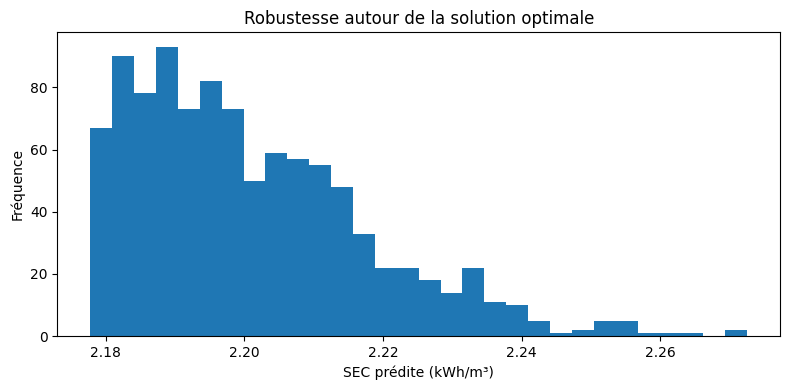

In [16]:
rng = np.random.default_rng(42)

N_ROBUSTNESS = 1000
X_robust = np.tile(x_global, (N_ROBUSTNESS, 1))

for j, feature in enumerate(FEATURES):
    low, high = PHYSICAL_BOUNDS[feature]
    perturbation = 0.02 * (high - low)

    X_robust[:, j] += rng.normal(
        0,
        perturbation,
        N_ROBUSTNESS
    )

    X_robust[:, j] = np.clip(
        X_robust[:, j],
        low,
        high
    )

robust_predictions = predict_sec_physical(
    pd.DataFrame(X_robust, columns=FEATURES)
)

print(f"SEC moyenne : {robust_predictions.mean():.6f}")
print(f"SEC médiane : {np.median(robust_predictions):.6f}")
print(f"SEC min : {robust_predictions.min():.6f}")
print(f"SEC max : {robust_predictions.max():.6f}")
print(f"Écart-type : {robust_predictions.std():.6f}")

plt.figure(figsize=(8, 4))
plt.hist(robust_predictions, bins=30)
plt.xlabel("SEC prédite (kWh/m³)")
plt.ylabel("Fréquence")
plt.title("Robustesse autour de la solution optimale")
plt.tight_layout()
plt.show()

# 15. Optimum robuste

Nous cherchons une solution qui minimise la SEC tout en évitant de se placer systématiquement aux extrêmes de toutes les variables.

La pénalisation est faible : la SEC reste prioritaire.

In [17]:
centers = np.array([
    (PHYSICAL_BOUNDS[f][0] + PHYSICAL_BOUNDS[f][1]) / 2
    for f in FEATURES
])

half_ranges = np.array([
    (PHYSICAL_BOUNDS[f][1] - PHYSICAL_BOUNDS[f][0]) / 2
    for f in FEATURES
])

def robust_objective(x):
    sec = objective_physical(x)

    normalized_distance = np.mean(
        ((np.asarray(x) - centers) /
         (half_ranges + 1e-12)) ** 2
    )

    return sec + 0.02 * normalized_distance

robust_result = differential_evolution(
    robust_objective,
    bounds=[PHYSICAL_BOUNDS[f] for f in FEATURES],
    seed=42,
    maxiter=500,
    popsize=20,
    tol=1e-8,
    atol=1e-8,
    polish=True,
)

x_robust = robust_result.x
robust_sec = objective_physical(x_robust)

print("Robust success :", robust_result.success)
print("Robust message :", robust_result.message)
print(f"SEC optimum robuste : {robust_sec:.6f} kWh/m³")

Robust success : True
Robust message : Optimization terminated successfully.
SEC optimum robuste : 2.177702 kWh/m³


# 16. Comparaison des scénarios

,Scenario,SEC_kWh_m3,Gain_vs_Reference_%
0,Reference,3.555801,0.000000
1,ML global optimum,2.177702,38.756345
2,ML robust optimum,2.177702,38.756345
3,Local verification,2.177702,38.756345


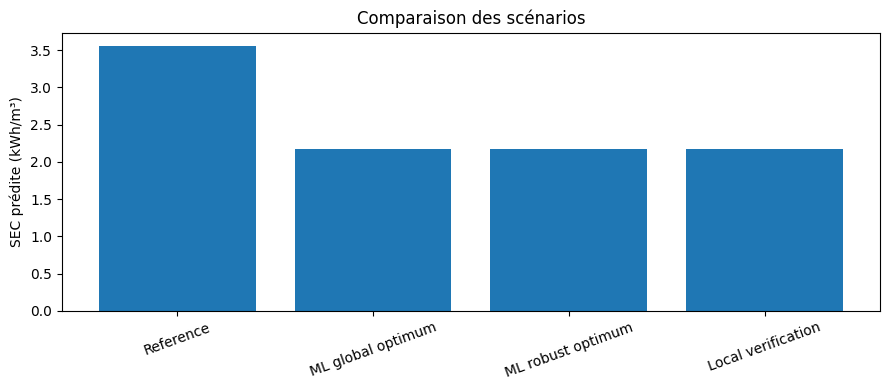

In [18]:
scenarios = pd.DataFrame([
    {
        "Scenario": "Reference",
        "SEC_kWh_m3": reference_sec,
    },
    {
        "Scenario": "ML global optimum",
        "SEC_kWh_m3": global_sec,
    },
    {
        "Scenario": "ML robust optimum",
        "SEC_kWh_m3": robust_sec,
    },
    {
        "Scenario": "Local verification",
        "SEC_kWh_m3": local_sec,
    },
])

scenarios["Gain_vs_Reference_%"] = (
    (reference_sec - scenarios["SEC_kWh_m3"])
    / reference_sec
    * 100
)

display(scenarios)

plt.figure(figsize=(9, 4))
plt.bar(
    scenarios["Scenario"],
    scenarios["SEC_kWh_m3"]
)
plt.ylabel("SEC prédite (kWh/m³)")
plt.title("Comparaison des scénarios")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 17. Comparaison physique des conditions

In [19]:
conditions_comparison = pd.DataFrame({
    "Feature": FEATURES,
    "Reference": x_reference,
    "Global_Optimum": x_global,
    "Robust_Optimum": x_robust,
})

display(conditions_comparison)

,Feature,Reference,Global_Optimum,Robust_Optimum
0,pressure_bar,62.387929,55.000000,55.000000
1,feed_flow_m3_h,604.717421,1000.000000,1000.000000
2,salinity_g_L,38.016545,42.000000,42.000000
3,temperature_C,22.500454,15.000000,15.000000
4,recovery_rate_target,0.374058,0.450000,0.450000
5,pump_efficiency,0.825914,0.899991,0.899991
6,erd_efficiency,0.880674,0.959950,0.959950
7,membrane_condition,0.874808,0.750033,0.750033


# 18. Vérification du domaine observé

L'optimum doit rester dans les valeurs réellement présentes dans le dataset synthétique.

In [20]:
domain_rows = []

for i, feature in enumerate(FEATURES):
    observed_min = float(df[feature].min())
    observed_max = float(df[feature].max())

    domain_rows.append({
        "Feature": feature,
        "Global_Optimum": x_global[i],
        "Observed_Min": observed_min,
        "Observed_Max": observed_max,
        "Inside_Observed_Domain": (
            observed_min <= x_global[i] <= observed_max
        ),
    })

domain_check = pd.DataFrame(domain_rows)
display(domain_check)

print(
    "Optimum entièrement dans le domaine observé :",
    bool(domain_check["Inside_Observed_Domain"].all())
)

,Feature,Global_Optimum,Observed_Min,Observed_Max,Inside_Observed_Domain
0,pressure_bar,55.000000,55.000175,69.995765,False
1,feed_flow_m3_h,1000.000000,200.126196,999.939861,False
2,salinity_g_L,42.000000,34.000385,41.999208,False
3,temperature_C,15.000000,15.000083,29.996841,False
4,recovery_rate_target,0.450000,0.300003,0.449996,False
5,pump_efficiency,0.899991,0.750001,0.899991,True
6,erd_efficiency,0.959950,0.800043,0.959950,True
7,membrane_condition,0.750033,0.750033,0.999969,True


Optimum entièrement dans le domaine observé : False


# 19. Analyse de sensibilité locale

Nous faisons varier une variable à la fois autour de l'optimum.

Cela permet de visualiser les directions dans lesquelles la SEC augmente ou diminue.

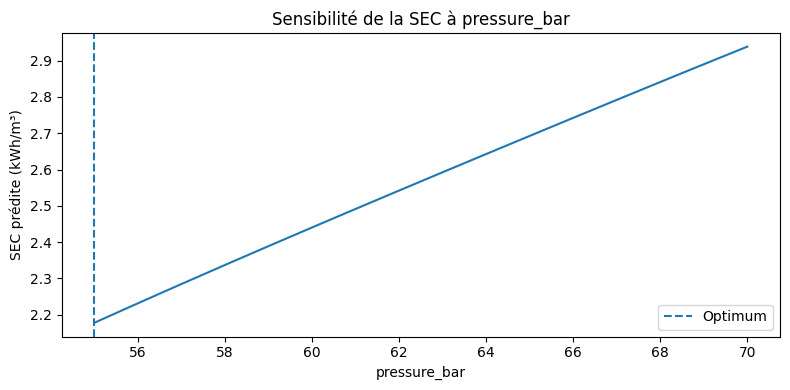

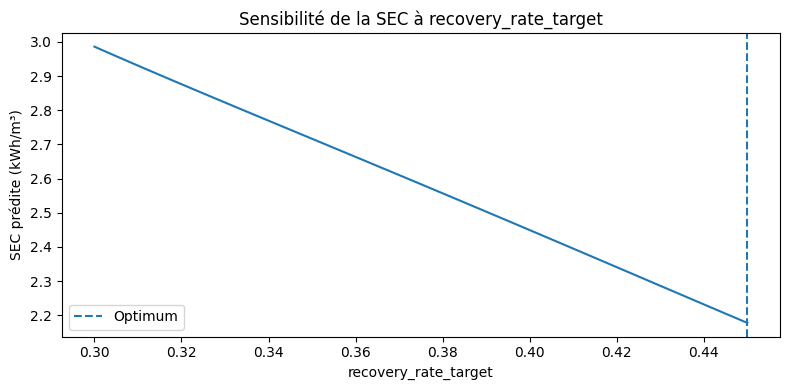

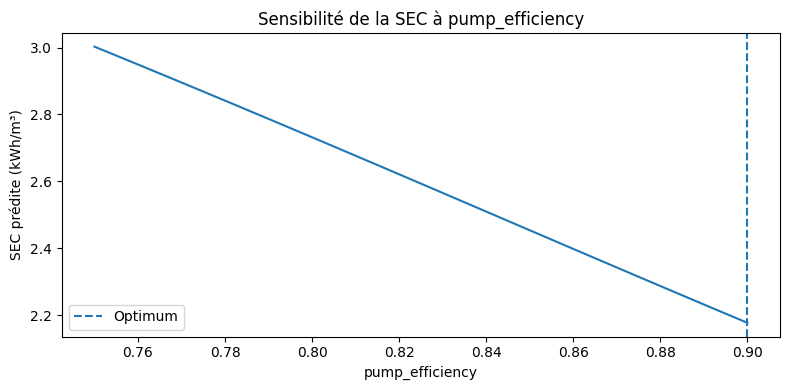

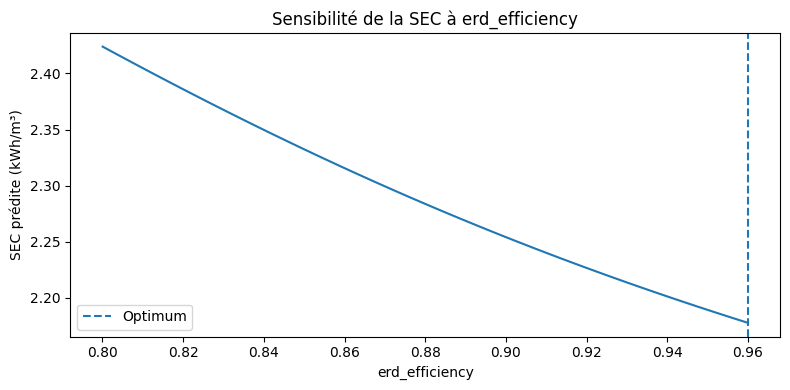

In [21]:
sensitivity_features = [
    "pressure_bar",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
]

for feature in sensitivity_features:
    j = FEATURES.index(feature)
    low, high = PHYSICAL_BOUNDS[feature]

    values = np.linspace(low, high, 100)

    X_grid = np.tile(x_global, (len(values), 1))
    X_grid[:, j] = values

    predictions = predict_sec_physical(
        pd.DataFrame(X_grid, columns=FEATURES)
    )

    plt.figure(figsize=(8, 4))
    plt.plot(values, predictions)
    plt.axvline(
        x_global[j],
        linestyle="--",
        label="Optimum"
    )
    plt.xlabel(feature)
    plt.ylabel("SEC prédite (kWh/m³)")
    plt.title(f"Sensibilité de la SEC à {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 20. Export des résultats

In [22]:
optimal_conditions.to_csv(
    RESULT_DIR / "optimization_v3_conditions.csv",
    index=False
)

boundary_check.to_csv(
    RESULT_DIR / "optimization_v3_boundary_check.csv",
    index=False
)

domain_check.to_csv(
    RESULT_DIR / "optimization_v3_domain_check.csv",
    index=False
)

conditions_comparison.to_csv(
    RESULT_DIR / "optimization_v3_scenarios_conditions.csv",
    index=False
)

scenarios.to_csv(
    RESULT_DIR / "optimization_v3_scenarios.csv",
    index=False
)

metrics = pd.DataFrame({
    "Metric": [
        "Reference_SEC",
        "Global_Optimum_SEC",
        "Robust_Optimum_SEC",
        "Local_Verification_SEC",
        "Predicted_Gain_kWh_m3",
        "Predicted_Gain_percent",
    ],
    "Value": [
        reference_sec,
        global_sec,
        robust_sec,
        local_sec,
        gain_absolute,
        gain_percent,
    ],
})

metrics.to_csv(
    RESULT_DIR / "optimization_v3_metrics.csv",
    index=False
)

print("Résultats sauvegardés dans :", RESULT_DIR.resolve())

Résultats sauvegardés dans : C:\Users\ilias\OneDrive\Documents\PFE\desalement\results


# 21. Conclusion méthodologique

### Ce que nous pouvons conclure

Le Notebook 06 utilise le MLP comme **modèle de substitution (surrogate model)** pour rechercher une configuration minimisant la SEC.

Le protocole est :

```text
Dataset physique SWRO V3
        ↓
Standardisation du Notebook 02
        ↓
MLP optimisé du Notebook 04
        ↓
Variables physiques proposées
        ↓
Reconstruction du scaling
        ↓
SEC prédite
        ↓
Optimisation sous contraintes
        ↓
Optimum ML
        ↓
Analyse de robustesse
```

### Limitation essentielle

Le gain énergétique obtenu ici reste une **prédiction du modèle ML**.

Il doit être confronté au modèle physique SWRO V3 dans le **Notebook 07**.

### Prochaine étape

**Notebook 07 — Validation physique de l'optimum**

Nous calculerons pour les mêmes conditions :

- SEC du modèle physique ;
- SEC prédite par le MLP ;
- erreur ML ;
- comparaison référence / optimum ;
- cohérence des contraintes physiques.

Cela permettra de vérifier que l'optimisation ML n'est pas seulement un artefact du réseau neuronal.